# Second-stage plotting notebook (organized)

This notebook is structured like a small plotting library so you can extend it later without rewriting everything.

## Suggested workflow
1. Run the setup/config cell.
2. Run the data-loading and ranking cells.
3. Run the plotting helper cells.
4. Run the final execution cell.

## Where to extend later
- Add new metrics in **Metric aggregation helpers**
- Add new figure types in **Plot builders**
- Add new selection logic in **Ranking helpers**
- Add new outputs in **run_all_plots()**


In [ ]:
import sys
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib import colors as mcolors

# ============================================================
# CONFIG
# ============================================================

ROOT = Path("/Users/andreali/Documents/Subgraph_Federated_Learning/")

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from andrea.multigraph_generation import TASKS

HP_COLS = [
    "mcw_norm",
    "num_layers",
    "lr",
    "weight_decay",
    "dropout",
    "hidden_dim",
    "use_ego_ids",
    "batch_size",
]

size = "small" # medium or small or big

TOPK = 4
VAL_TASKS_TO_PLOT = list(TASKS)

TRAIN_SELECTED_EXPERIMENT_LOG_PATH = Path(f"./experiment_{size}_graph.csv")
OUT_ROOT = f"model_logs_{size}_graph"

print("experiment path:", TRAIN_SELECTED_EXPERIMENT_LOG_PATH)
print("experiment model-logs:", OUT_ROOT)

PLOTS_ROOT = (
    Path.cwd()
    / "experiment_plots"
    / f"{size}_graph"
)
print("out figure:", PLOTS_ROOT)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

experiment path: experiment_medium_graph.csv
experiment model-logs: model_logs_medium_graph
out figure: /Users/andreali/Documents/Subgraph_Federated_Learning/andrea/test_model_ability/experiment_plots/medium_graph


## General helpers

Keep generic utilities here.  
If you add a new file format, a new path rule, or a new summary statistic, add it in this section.


In [23]:
# ============================================================
# GENERAL HELPERS
# ============================================================

def normalize_mcw(x):
    if pd.isna(x):
        return "None"
    return str(x)

def stderr(x):
    x = pd.Series(x).dropna()
    if len(x) <= 1:
        return 0.0
    return x.std(ddof=1) / np.sqrt(len(x))

def resolve_existing_path(path_like):
    p = Path(path_like)
    candidates = [
        p,
        Path.cwd() / p,
        ROOT / p,
        Path("/mnt/data") / p.name,
        Path("/mnt/data") / str(p).replace("andrea/", ""),
        ROOT / str(p).replace("andrea/", ""),
    ]
    for cand in candidates:
        if cand.exists():
            return cand.resolve()
    raise FileNotFoundError(f"Could not resolve path: {path_like}")

def resolve_run_dir(out_dir):
    p = Path(str(out_dir))
    candidates = [
        p,
        Path.cwd() / p,
        ROOT / p,
        ROOT / str(p).replace("andrea/", ""),
        Path("/mnt/data") / p,
        Path("/mnt/data") / str(p).replace("andrea/", ""),
    ]
    for cand in candidates:
        if cand.exists():
            return cand.resolve()
    return None

def load_local_run(run_dir: Path) -> pd.DataFrame:
    local_csv = resolve_existing_path(run_dir)
    if not local_csv.exists():
        raise FileNotFoundError(f"Missing csv file: {run_dir}")
    return pd.read_csv(local_csv)

def aggregate_curve(curves, x_col, y_col):
    if not curves:
        return pd.DataFrame(columns=[x_col, "mean", "std", "n"])
    df = pd.concat(curves, ignore_index=True)
    out = (
        df.groupby(x_col, as_index=False)[y_col]
          .agg(mean="mean", std="std", n="count")
          .sort_values(x_col)
    )
    out["std"] = out["std"].fillna(0.0)
    return out

def show_selected_overview(selected, tasks):
    row = selected.iloc[0] if isinstance(selected, pd.DataFrame) else selected

    meta_cols = ["graph_id", "dataset_id", "type", "selected_profile"]
    for col in meta_cols:
        if col in row.index:
            print(f"{col}: {row[col]}")

    records = []
    for task in tasks:
        records.append(
            {
                "task": task,
                "pos_rate_mean": row.get(f"{task}_pos_rate_mean", pd.NA),
                "pos_rate_max_diff_from_mean": row.get(f"{task}_pos_rate_max_diff_from_mean", pd.NA),
                "pos_nodes_mean": row.get(f"{task}_pos_nodes_mean", pd.NA),
                "pos_nodes_max_diff_from_mean": row.get(f"{task}_pos_nodes_max_diff_from_mean", pd.NA),
            }
        )

    overview = pd.DataFrame(records)
    for c in [
        "pos_rate_mean",
        "pos_rate_max_diff_from_mean",
        "pos_nodes_mean",
        "pos_nodes_max_diff_from_mean",
    ]:
        if c in overview.columns:
            overview[c] = pd.to_numeric(overview[c], errors="coerce").round(3)

    display(overview)
    print()
    return overview

def always_one_metrics(pos_rate: float) -> dict:
    p = float(pos_rate)
    f1 = 0.0 if p <= 0.0 else (2.0 * p) / (1.0 + p)
    return {"threshold": 0.0, "f1": f1, "auprc": p}

def build_always_one_baseline(graph_row, split_name, task_order):
    rows = []
    for task in task_order:
        split_col = f"{split_name}_{task}_pos_rate_mean"
        generic_col = f"{task}_pos_rate_mean"
        pos_rate = graph_row.get(split_col, graph_row.get(generic_col, np.nan))
        if pd.isna(pos_rate):
            continue
        m = always_one_metrics(pos_rate)
        rows.append(
            {
                "task": task,
                "threshold": m["threshold"],
                "f1": m["f1"],
                "auprc": m["auprc"],
            }
        )
    return pd.DataFrame(rows)

## Load experiment tables

This cell only loads and normalizes the experiment metadata.  
Nothing here should do ranking or plotting yet.


In [24]:
# ============================================================
# LOAD EXPERIMENT TABLE ONLY
# ============================================================

all_exp = pd.read_csv(resolve_existing_path(TRAIN_SELECTED_EXPERIMENT_LOG_PATH))
print("Loaded experiment rows:", len(all_exp))

# ------------------------------
# normalize hyperparameter cols
# ------------------------------
if "mcw_norm" not in all_exp.columns:
    all_exp["mcw_norm"] = all_exp["mcw"].astype(str)


all_exp["run_exists"] = all_exp["out_dir"].apply(
    lambda p: resolve_existing_path(p).exists() if p is not None else False
)

print("Rows with existing local.csv:", int(all_exp["run_exists"].sum()))


base_graph_cols = [
    "graph_id",
    "dataset_id",
    "selected_profile",
    "type",
    "data_dir",
]

task_stat_cols = sorted(
    [
        c
        for c in all_exp.columns
        if (
            c.endswith("_pos_nodes_mean")
            or c.endswith("_pos_rate_mean")
            or c.endswith("_pos_nodes_max_diff_from_mean")
            or c.endswith("_pos_rate_max_diff_from_mean")
        )
    ]
)

graph_cols = [c for c in base_graph_cols if c in all_exp.columns] + task_stat_cols
graph_cols = list(dict.fromkeys(graph_cols))

train_graphs = (
    all_exp.sort_values(["graph_id", "seed"])
    .drop_duplicates(subset=["graph_id"])
    [graph_cols]
    .reset_index(drop=True)
)

print("Unique graphs found in experiment log:", len(train_graphs))
display(train_graphs.head())

Loaded experiment rows: 15
Rows with existing local.csv: 15
Unique graphs found in experiment log: 3


,graph_id,dataset_id,selected_profile,type,data_dir,cycle2_pos_nodes_max_diff_from_mean,cycle2_pos_nodes_mean,cycle2_pos_rate_max_diff_from_mean,cycle2_pos_rate_mean,cycle3_pos_nodes_max_diff_from_mean,cycle3_pos_nodes_mean,cycle3_pos_rate_max_diff_from_mean,cycle3_pos_rate_mean,cycle4_pos_nodes_max_diff_from_mean,cycle4_pos_nodes_mean,cycle4_pos_rate_max_diff_from_mean,cycle4_pos_rate_mean,cycle5_pos_nodes_max_diff_from_mean,cycle5_pos_nodes_mean,cycle5_pos_rate_max_diff_from_mean,cycle5_pos_rate_mean,cycle6_pos_nodes_max_diff_from_mean,cycle6_pos_nodes_mean,cycle6_pos_rate_max_diff_from_mean,cycle6_pos_rate_mean
0,141,data_4000_5_2.5_chordal,flat,chordal,./andrea/test_data/data_4000_5_2.5_chordal,46.666667,1765.666667,0.011667,0.441417,80.666667,1873.333333,0.020167,0.468333,71.0,1916.0,0.01775,0.4790,124.333333,1819.333333,0.031083,0.454833,38.000000,1674.000000,0.009500,0.418500
1,467,data_4000_5_1.5_chordal,decreasing,chordal,./andrea/test_data/data_4000_5_1.5_chordal,10.000000,2241.000000,0.002500,0.560250,53.666667,1977.666667,0.013417,0.494417,30.0,1536.0,0.00750,0.3840,48.666667,1066.666667,0.012167,0.266667,22.000000,623.000000,0.005500,0.155750
2,660,data_4000_5_11_chordal,increasing,chordal,./andrea/test_data/data_4000_5_11_chordal,22.000000,563.000000,0.005500,0.140750,42.666667,888.666667,0.010667,0.222167,30.0,1350.0,0.00750,0.3375,41.666667,1848.666667,0.010417,0.462167,68.333333,2247.666667,0.017083,0.561917


## Ranking helpers

This section builds:
- run-level summaries
- config-level summaries across seeds
- top-k configs per graph

If later you want a different ranking rule, edit this section only.


In [25]:
# ============================================================
# RANKING HELPERS
# ============================================================

def hp_key_from_row(r):
    return tuple(r[c] for c in HP_COLS)

def hp_label_from_key(key):
    d = dict(zip(HP_COLS, key))
    ego_flag = bool(d["use_ego_ids"])
    ego_label = "ego=True" if ego_flag else "ego=False"
    return (
        f"mcw={d['mcw_norm']} | "
        f"L={int(d['num_layers'])} | "
        f"lr={d['lr']} | "
        f"wd={d['weight_decay']} | "
        f"do={d['dropout']} | "
        f"hd={int(d['hidden_dim'])} | "
        f"{ego_label} | "
        f"bs={int(d['batch_size'])}"
    )

def config_label_from_row(r):
    return hp_label_from_key(hp_key_from_row(r))

def summarize_one_run(exp_row):
    run_dir = exp_row["out_dir"]
    if run_dir is None:
        return None

    df = load_local_run(run_dir)

    best_val = df[df["phase"] == "best_val"]
    best_train = df[df["phase"] == "best_train"]
    best_test = df[df["phase"] == "best_test"]

    if best_val.empty or best_train.empty:
        return None

    best_val = best_val.iloc[-1]
    best_train = best_train.iloc[-1]
    best_test = best_test.iloc[-1] if not best_test.empty else None

    stopped_epoch = (
        int(df[df["phase"] == "val"]["local_epoch"].max())
        if (df["phase"] == "val").any()
        else -1
    )

    out = {
        "graph_id": exp_row["graph_id"],
        "seed": exp_row["seed"],
        **{c: exp_row[c] for c in HP_COLS},
        "config": exp_row["config"],
        "out_dir": exp_row["out_dir"],
        "run_dir": str(run_dir),
        "best_epoch": int(best_val.get("best_epoch", -1)),
        "stopped_epoch": stopped_epoch,
        "best_train_eval_loss": float(best_train.get("eval_loss", np.nan)),
        "best_val_eval_loss": float(best_val.get("eval_loss", np.nan)),
        "best_val_micro_f1": float(best_val.get("micro_f1", np.nan)),
        "best_val_macro_f1": float(best_val.get("macro_f1", np.nan)),
        "best_val_macro_pos_f1": float(best_val.get("macro_pos_f1", np.nan)),
        "best_val_macro_minority_f1": float(best_val.get("macro_minority_f1", np.nan)),
    }
    out["gap_eval_loss"] = out["best_val_eval_loss"] - out["best_train_eval_loss"]

    if best_test is not None:
        out["best_test_eval_loss"] = float(best_test.get("eval_loss", np.nan))
        out["best_test_micro_f1"] = float(best_test.get("micro_f1", np.nan))
        out["best_test_macro_f1"] = float(best_test.get("macro_f1", np.nan))
        out["best_test_macro_pos_f1"] = float(best_test.get("macro_pos_f1", np.nan))
        out["best_test_macro_minority_f1"] = float(best_test.get("macro_minority_f1", np.nan))

    return out

def build_ranked_tables(all_exp_df):
    work = all_exp_df.copy()
    work["config"] = work.apply(config_label_from_row, axis=1)

    rows = []
    for _, r in work[work["run_exists"]].iterrows():
        s = summarize_one_run(r)
        if s is not None:
            rows.append(s)

    run_summary = pd.DataFrame(rows)
    print("Runs with local.csv parsed:", len(run_summary))

    if run_summary.empty:
        hp_summary = pd.DataFrame()
        hp_summary_full = pd.DataFrame()
        topk_hp = pd.DataFrame()
        required_seeds = 0
        return work, run_summary, hp_summary, hp_summary_full, topk_hp, required_seeds

    group_cols = ["graph_id"] + HP_COLS
    hp_summary = (
        run_summary.groupby(group_cols, as_index=False)
        .agg(
            n_seeds=("seed", "nunique"),
            val_loss_mean=("best_val_eval_loss", "mean"),
            val_loss_stderr=("best_val_eval_loss", stderr),
            gap_mean=("gap_eval_loss", "mean"),
            gap_stderr=("gap_eval_loss", stderr),
            micro_f1_mean=("best_val_micro_f1", "mean"),
            micro_f1_stderr=("best_val_micro_f1", stderr),
            macro_f1_mean=("best_val_macro_f1", "mean"),
            macro_f1_stderr=("best_val_macro_f1", stderr),
            macro_pos_f1_mean=("best_val_macro_pos_f1", "mean"),
            macro_pos_f1_stderr=("best_val_macro_pos_f1", stderr),
            macro_minority_f1_mean=("best_val_macro_minority_f1", "mean"),
            macro_minority_f1_stderr=("best_val_macro_minority_f1", stderr),
            stopped_epoch_mean=("stopped_epoch", "mean"),
        )
    )

    required_seeds = int(work["seed"].nunique())
    hp_summary_full = hp_summary[hp_summary["n_seeds"] == required_seeds].copy()

    hp_summary_full = hp_summary_full.sort_values(
        [
            "graph_id",
            "val_loss_mean",
            "gap_mean",
            "macro_minority_f1_mean",
            "macro_f1_mean",
            "micro_f1_mean",
        ],
        ascending=[True, True, True, False, False, False],
    )

    topk_hp = hp_summary_full.groupby("graph_id").head(TOPK).copy()
    return work, run_summary, hp_summary, hp_summary_full, topk_hp, required_seeds

def top_configs_for_graph(topk_hp_df, graph_id):
    rows = topk_hp_df[topk_hp_df["graph_id"] == graph_id].copy()
    return rows.apply(
        lambda r: hp_label_from_key(tuple(r[c] for c in HP_COLS)), axis=1
    ).tolist()

def build_global_config_summary(hp_summary_full_df):
    if hp_summary_full_df.empty:
        return pd.DataFrame(), 0

    total_graphs = int(hp_summary_full_df["graph_id"].nunique())

    group_cols = HP_COLS
    global_summary = (
        hp_summary_full_df.groupby(group_cols, as_index=False)
        .agg(
            n_graphs=("graph_id", "nunique"),
            val_loss_mean_across_graphs=("val_loss_mean", "mean"),
            val_loss_stderr_across_graphs=("val_loss_mean", stderr),
            gap_mean_across_graphs=("gap_mean", "mean"),
            gap_stderr_across_graphs=("gap_mean", stderr),
            micro_f1_mean_across_graphs=("micro_f1_mean", "mean"),
            macro_f1_mean_across_graphs=("macro_f1_mean", "mean"),
            macro_pos_f1_mean_across_graphs=("macro_pos_f1_mean", "mean"),
            macro_minority_f1_mean_across_graphs=("macro_minority_f1_mean", "mean"),
            stopped_epoch_mean_across_graphs=("stopped_epoch_mean", "mean"),
        )
    )

    global_summary_full = global_summary[global_summary["n_graphs"] == total_graphs].copy()

    global_summary_full = global_summary_full.sort_values(
        [
            "val_loss_mean_across_graphs",
            "gap_mean_across_graphs",
            "macro_minority_f1_mean_across_graphs",
            "macro_f1_mean_across_graphs",
            "micro_f1_mean_across_graphs",
        ],
        ascending=[True, True, False, False, False],
    )

    return global_summary_full, total_graphs

def print_best_overall_configuration(global_summary_df, total_graphs):
    print(f"\nBest overall configuration across {total_graphs} graphs:")

    if global_summary_df.empty:
        print("No configuration has full coverage across all graphs.")
        return None

    best = global_summary_df.iloc[0]
    best_label = hp_label_from_key(tuple(best[c] for c in HP_COLS))

    print(best_label)
    print(
        f"n_graphs={int(best['n_graphs'])} | "
        f"val_loss={best['val_loss_mean_across_graphs']:.4f} | "
        f"gap={best['gap_mean_across_graphs']:.4f} | "
        f"macro_minority_f1={best['macro_minority_f1_mean_across_graphs']:.4f} | "
        f"macro_f1={best['macro_f1_mean_across_graphs']:.4f} | "
        f"micro_f1={best['micro_f1_mean_across_graphs']:.4f} | "
        f"stopped_epoch={best['stopped_epoch_mean_across_graphs']:.2f}"
    )
    return best

def best_global_config_label(best_global_config_row):
    if best_global_config_row is None:
        return None
    return hp_label_from_key(tuple(best_global_config_row[c] for c in HP_COLS))

def best_config_for_graph(topk_hp_df, graph_id):
    rows = topk_hp_df[topk_hp_df["graph_id"] == graph_id].copy()
    if rows.empty:
        return None
    r = rows.iloc[0]
    return hp_label_from_key(tuple(r[c] for c in HP_COLS))

In [26]:
all_exp, run_summary, hp_summary, hp_summary_full, topk_hp, REQUIRED_SEEDS = build_ranked_tables(all_exp)

print(f"\nRequired complete seeds per config: {REQUIRED_SEEDS}")

print("\nTopK configs per graph (aggregated over seeds):")
if topk_hp.empty:
    print("No fully-complete TOPK table was built.")
else:
    display(
        topk_hp[
            [
                "graph_id",
                "n_seeds",
                "val_loss_mean",
                "gap_mean",
                "micro_f1_mean",
                "macro_f1_mean",
                "macro_pos_f1_mean",
                "macro_minority_f1_mean",
                "stopped_epoch_mean",
            ] + HP_COLS
        ]
    )

global_summary, N_GRAPHS = build_global_config_summary(hp_summary_full)

print("\nGlobal config ranking (configs that appear on all graphs):")
if global_summary.empty:
    print("No globally-complete configuration table was built.")
else:
    display(
        global_summary[
            [
                "n_graphs",
                "val_loss_mean_across_graphs",
                "gap_mean_across_graphs",
                "micro_f1_mean_across_graphs",
                "macro_f1_mean_across_graphs",
                "macro_pos_f1_mean_across_graphs",
                "macro_minority_f1_mean_across_graphs",
                "stopped_epoch_mean_across_graphs",
            ] + HP_COLS
        ].head(5)
    )

BEST_GLOBAL_CONFIG = print_best_overall_configuration(global_summary, N_GRAPHS)

Runs with local.csv parsed: 15

Required complete seeds per config: 5

TopK configs per graph (aggregated over seeds):


,graph_id,n_seeds,val_loss_mean,gap_mean,micro_f1_mean,macro_f1_mean,macro_pos_f1_mean,macro_minority_f1_mean,stopped_epoch_mean,mcw_norm,num_layers,lr,weight_decay,dropout,hidden_dim,use_ego_ids,batch_size
0,141,5,0.101253,0.034895,0.960339,0.958809,0.958809,0.958809,80.0,auto,6,0.001,0.0001,0.1,64,True,64
1,467,5,0.166541,0.062435,0.938457,0.904722,0.904722,0.904490,80.0,auto,6,0.001,0.0001,0.1,64,True,64
2,660,5,0.133236,0.008375,0.929055,0.940518,0.940518,0.933408,80.0,auto,6,0.001,0.0001,0.1,64,True,64



Global config ranking (configs that appear on all graphs):


,n_graphs,val_loss_mean_across_graphs,gap_mean_across_graphs,micro_f1_mean_across_graphs,macro_f1_mean_across_graphs,macro_pos_f1_mean_across_graphs,macro_minority_f1_mean_across_graphs,stopped_epoch_mean_across_graphs,mcw_norm,num_layers,lr,weight_decay,dropout,hidden_dim,use_ego_ids,batch_size
0,3,0.133677,0.035235,0.942617,0.934683,0.934683,0.932235,80.0,auto,6,0.001,0.0001,0.1,64,True,64



Best overall configuration across 3 graphs:
mcw=auto | L=6 | lr=0.001 | wd=0.0001 | do=0.1 | hd=64 | ego=True | bs=64
n_graphs=3 | val_loss=0.1337 | gap=0.0352 | macro_minority_f1=0.9322 | macro_f1=0.9347 | micro_f1=0.9426 | stopped_epoch=80.00


## Plot data collectors and aggregation helpers

This section prepares the exact data slices used by the figure builders.


In [27]:
# ============================================================
# DATA COLLECTION FOR PLOTTING
# ============================================================

def collect_graph_runs(all_exp_df, graph_id):
    runs = all_exp_df[all_exp_df["graph_id"] == graph_id].copy()
    runs["run_dir"] = runs["out_dir"].apply(resolve_run_dir)
    runs["run_exists"] = runs["run_dir"].apply(lambda x: x is not None)
    return runs

def summarize_best_split(graph_runs, split_name):
    scalar_rows = []
    task_rows = []
    scalar_phase = f"best_{split_name}"
    task_phase = f"best_{split_name}_task"

    for _, run in graph_runs.iterrows():
        run_dir = run["run_dir"]
        if run_dir is None:
            continue

        local_df = load_local_run(run_dir)

        scalar_part = local_df[local_df["phase"] == scalar_phase].copy()
        if not scalar_part.empty:
            row = scalar_part.iloc[-1].to_dict()
            row.update(
                {
                    "graph_id": run["graph_id"],
                    "config": run["config"],
                    "seed": run["seed"],
                    "run_dir": str(run_dir),
                    "split": split_name,
                }
            )
            scalar_rows.append(row)

        task_part = local_df[local_df["phase"] == task_phase].copy()
        if not task_part.empty:
            task_part = task_part.assign(
                graph_id=run["graph_id"],
                config=run["config"],
                seed=run["seed"],
                run_dir=str(run_dir),
                split=split_name,
            )
            task_rows.append(task_part)

    scalar_df = pd.DataFrame(scalar_rows)
    task_df = pd.concat(task_rows, ignore_index=True) if task_rows else pd.DataFrame()
    return scalar_df, task_df

def summarize_val_task_per_epoch(graph_runs):
    task_rows = []

    for _, run in graph_runs.iterrows():
        run_dir = run["run_dir"]
        if run_dir is None:
            continue

        local_df = load_local_run(run_dir)
        part = local_df[local_df["phase"] == "val_task"].copy()
        if part.empty:
            continue

        part = part.assign(
            graph_id=run["graph_id"],
            config=run["config"],
            seed=run["seed"],
            run_dir=str(run_dir),
        )
        task_rows.append(part)

    return pd.concat(task_rows, ignore_index=True) if task_rows else pd.DataFrame()

def aggregate_task_metric(task_df, metric_col):
    if task_df.empty:
        return pd.DataFrame(columns=["config", "task", "mean", "std", "n"])
    out = (
        task_df.groupby(["config", "task"], as_index=False)[metric_col]
               .agg(mean="mean", std="std", n="count")
    )
    out["std"] = out["std"].fillna(0.0)
    return out

def aggregate_scalar_metric(scalar_df, metric_col):
    if scalar_df.empty:
        return pd.DataFrame(columns=["config", "mean", "std", "n"])
    out = (
        scalar_df.groupby("config", as_index=False)[metric_col]
                 .agg(mean="mean", std="std", n="count")
    )
    out["std"] = out["std"].fillna(0.0)
    return out

def aggregate_epoch_task_metric(task_df, metric_col):
    if task_df.empty:
        return pd.DataFrame(columns=["config", "task", "local_epoch", "mean", "std", "n"])
    out = (
        task_df.groupby(["config", "task", "local_epoch"], as_index=False)[metric_col]
               .agg(mean="mean", std="std", n="count")
               .sort_values(["config", "task", "local_epoch"])
    )
    out["std"] = out["std"].fillna(0.0)
    return out

## Figure builders

Add new plot functions here.  
Try to keep each function responsible for one figure only.


In [28]:
# ============================================================
# FIGURE BUILDERS
# ============================================================

def get_positive_task_summary(graph_row, task_names):
    positive_tasks = []
    task_stats = []

    for task in task_names:
        pos_nodes = pd.to_numeric(
            graph_row.get(f"{task}_pos_nodes_mean", np.nan), errors="coerce"
        )
        pos_rate = pd.to_numeric(
            graph_row.get(f"{task}_pos_rate_mean", np.nan), errors="coerce"
        )

        if pd.notna(pos_nodes) and pos_nodes > 0:
            positive_tasks.append(task)

        task_stats.append(
            {
                "task": task,
                "pos_nodes_mean": None if pd.isna(pos_nodes) else float(pos_nodes),
                "pos_rate_mean": None if pd.isna(pos_rate) else float(pos_rate),
            }
        )

    return {
        "n_positive_tasks": int(len(positive_tasks)),
        "positive_tasks": positive_tasks,
        "positive_task_stats": task_stats,
    }


def build_positive_stats_footer(
    graph_row, task_names, only_positive=True, tasks_per_line=3
):
    entries = []

    for task in task_names:
        pos_nodes = pd.to_numeric(
            graph_row.get(f"{task}_pos_nodes_mean", np.nan), errors="coerce"
        )
        pos_rate = pd.to_numeric(
            graph_row.get(f"{task}_pos_rate_mean", np.nan), errors="coerce"
        )

        if only_positive and pd.notna(pos_nodes) and pos_nodes <= 0:
            continue

        pos_nodes_str = "NA" if pd.isna(pos_nodes) else f"{float(pos_nodes):.1f}"
        pos_rate_str = "NA" if pd.isna(pos_rate) else f"{float(pos_rate):.3f}"

        entries.append(f"{task}: pos_nodes={pos_nodes_str}, pos_rate={pos_rate_str}")

    if not entries:
        return "No positive-task statistics available."

    lines = []
    for i in range(0, len(entries), tasks_per_line):
        lines.append(" | ".join(entries[i : i + tasks_per_line]))

    return "\n".join(lines)


def make_loss_figure_for_graph(
    graph_row,
    graph_runs,
    save_root,
    configs,
    footer_text=None,
):
    n = len(configs)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows), squeeze=False)
    axes = axes.flatten()

    for ax, config in zip(axes, configs):
        cfg_runs = graph_runs[graph_runs["config"] == config].copy()

        train_curves, val_curves = [], []
        for _, run in cfg_runs.iterrows():
            run_dir = run["run_dir"]
            if run_dir is None:
                continue

            local_df = load_local_run(run_dir)
            val_df = local_df[local_df["phase"] == "val"].copy()
            if val_df.empty:
                continue

            train_curves.append(
                val_df[["local_epoch", "train_loss"]].rename(columns={"train_loss": "metric"})
            )
            val_curves.append(
                val_df[["local_epoch", "val_loss"]].rename(columns={"val_loss": "metric"})
            )

        if train_curves:
            train_agg = aggregate_curve(train_curves, "local_epoch", "metric")
            x = train_agg["local_epoch"].to_numpy(dtype=float)
            m = train_agg["mean"].to_numpy(dtype=float)
            s = train_agg["std"].to_numpy(dtype=float)
            ax.plot(x, m, marker="o", label="train_loss")
            ax.fill_between(x, m - s, m + s, alpha=0.2)

        if val_curves:
            val_agg = aggregate_curve(val_curves, "local_epoch", "metric")
            x = val_agg["local_epoch"].to_numpy(dtype=float)
            m = val_agg["mean"].to_numpy(dtype=float)
            s = val_agg["std"].to_numpy(dtype=float)
            ax.plot(x, m, marker="s", label="val_loss")
            ax.fill_between(x, m - s, m + s, alpha=0.2)

        n_seeds = int(cfg_runs["seed"].nunique()) if len(cfg_runs) else 0
        ax.set_title(f"{config}\n(n_seeds={n_seeds})")
        ax.set_xlabel("local_epoch")
        ax.set_ylabel("loss")
        ax.grid(alpha=0.3)
        ax.legend()

    for j in range(len(configs), len(axes)):
        axes[j].axis("off")

    fig.suptitle(
        f"graph_id={graph_row['graph_id']} | dataset={graph_row.get('dataset_id', 'NA')} | "
        f"profile={graph_row.get('selected_profile', 'NA')} | generator={graph_row.get('type', 'NA')}",
        y=0.98,
    )

    if footer_text is not None:
        fig.text(
            0.01,
            0.01,
            footer_text,
            ha="left",
            va="bottom",
            fontsize=13,
        )
        fig.tight_layout(rect=[0, 0.14, 1, 0.93])
    else:
        fig.tight_layout(rect=[0, 0.03, 1, 0.93])

    save_root.mkdir(parents=True, exist_ok=True)
    save_path = save_root / f"graph_{int(graph_row['graph_id'])}_losses_topk.png"
    fig.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.show()
    return save_path

def make_top1_val_epoch_task_figure_for_graph(
    graph_row,
    task_df,
    save_root,
    configs,
    task_subset=None,
    footer_text=None,
):
    if task_subset is None:
        task_subset = list(TASKS)

    if len(configs) == 0:
        print("No configs available.")
        return None

    top1_config = configs[0]
    sub_df = task_df[task_df["config"] == top1_config].copy()

    if sub_df.empty:
        print("No val_task rows found for top1 config.")
        return None

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), squeeze=False)
    axes = axes.flatten()

    metric_specs = [
        ("f1", "Validation F1 vs Epoch"),
        ("minority_f1", "Validation Minority F1 vs Epoch"),
    ]

    for ax, (metric_col, title) in zip(axes, metric_specs):
        agg = aggregate_epoch_task_metric(sub_df, metric_col)

        for task in task_subset:
            task_part = agg[agg["task"] == task].sort_values("local_epoch")
            if task_part.empty:
                continue

            x = task_part["local_epoch"].to_numpy(dtype=float)
            m = task_part["mean"].to_numpy(dtype=float)
            s = task_part["std"].to_numpy(dtype=float)

            ax.plot(x, m, marker="o", label=task)
            ax.fill_between(x, m - s, m + s, alpha=0.2)

        ax.set_title(f"{title}\n{top1_config}")
        ax.set_xlabel("local_epoch")
        ax.set_ylabel(metric_col)
        ax.set_ylim(0, 1.05)
        ax.grid(alpha=0.3)
        ax.legend()

    fig.suptitle(
        f"graph_id={graph_row['graph_id']} | dataset={graph_row.get('dataset_id', 'NA')} | "
        f"profile={graph_row.get('selected_profile', 'NA')} | generator={graph_row.get('type', 'NA')} | top1 config",
        y=0.98,
    )

    if footer_text is not None:
        fig.text(
            0.01,
            0.01,
            footer_text,
            ha="left",
            va="bottom",
            fontsize=14,
        )
        fig.tight_layout(rect=[0, 0.14, 1, 0.94])
    else:
        fig.tight_layout(rect=[0, 0.03, 1, 0.94])

    save_root.mkdir(parents=True, exist_ok=True)
    save_path = save_root / f"graph_{int(graph_row['graph_id'])}_top1_val_task_epoch_curves.png"
    fig.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.show()
    return save_path


def _text_color_from_norm(x, threshold=0.58):
    return "white" if x >= threshold else "black"


def _draw_heat_table(
    ax,
    color_values,
    text_values,
    row_labels,
    col_labels,
    title="",
    cmap="Greens",
    vmin=0.0,
    vmax=1.0,
    fontsize=11,
):
    cmap_obj = plt.get_cmap(cmap)
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    nrows, ncols = color_values.shape
    ax.imshow(color_values, cmap=cmap_obj, norm=norm, aspect="auto")

    ax.set_xticks(np.arange(ncols))
    ax.set_yticks(np.arange(nrows))
    ax.set_xticklabels(col_labels, fontsize=fontsize)
    ax.set_yticklabels(row_labels, fontsize=fontsize)

    ax.set_xticks(np.arange(-0.5, ncols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, nrows, 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=2)
    ax.tick_params(which="minor", bottom=False, left=False)

    plt.setp(ax.get_xticklabels(), rotation=0, ha="center")

    for i in range(nrows):
        for j in range(ncols):
            val = color_values[i, j]
            txt = text_values[i][j]
            txt_color = _text_color_from_norm(norm(val))
            ax.text(
                j,
                i,
                txt,
                ha="center",
                va="center",
                color=txt_color,
                fontsize=fontsize,
                linespacing=1.2,
            )

    ax.set_title(title, fontsize=fontsize + 1)
    for spine in ax.spines.values():
        spine.set_visible(False)


def _columnwise_color_matrix(
    values,
    col_labels,
    lower_is_better_cols=None,
    neutral_cols=None,
):
    if lower_is_better_cols is None:
        lower_is_better_cols = set()
    if neutral_cols is None:
        neutral_cols = set()

    values = np.asarray(values, dtype=float)
    out = np.full_like(values, 0.5, dtype=float)

    for j, col in enumerate(col_labels):
        if col in neutral_cols:
            out[:, j] = 0.5
            continue

        col_vals = values[:, j]
        finite = np.isfinite(col_vals)

        if finite.sum() == 0:
            out[:, j] = 0.5
            continue

        vmin = np.nanmin(col_vals[finite])
        vmax = np.nanmax(col_vals[finite])

        if abs(vmax - vmin) < 1e-12:
            if col in neutral_cols:
                out[:, j] = 0.78
            else:
                out[:, j] = 0.92
            continue

        normed = (col_vals - vmin) / (vmax - vmin)

        if col in lower_is_better_cols:
            normed = 1.0 - normed

        out[:, j] = normed

    return out


def _short_config_labels(configs):
    return [f"top{i+1}" for i in range(len(configs))]


def _config_mapping_text(configs):
    lines = []
    for i, cfg in enumerate(configs):
        lines.append(f"top{i+1} = {cfg}")
    return "\n".join(lines)


def make_task_metric_table_for_graph(
    graph_row,
    task_df,
    save_root,
    split_name,
    configs,
    footer_text=None,
    use_topk=False,
):
    if len(configs) == 0:
        print("No configs available.")
        return None

    used_configs = configs if use_topk else configs[:1]

    metric_specs = [
        ("positive_f1", "Positive F1"),
        ("minority_f1", "Minority F1"),
    ]
    task_order = list(TASKS)

    row_labels = []
    value_rows = []
    text_rows = []

    for cfg_idx, config in enumerate(used_configs):
        sub_df = task_df[task_df["config"] == config].copy()
        if sub_df.empty:
            continue

        for metric_col, metric_label in metric_specs:
            agg = aggregate_task_metric(sub_df, metric_col)

            row_vals = []
            row_txts = []
            for task in task_order:
                row = agg[agg["task"] == task]
                if row.empty:
                    mean_v = np.nan
                    std_v = np.nan
                else:
                    mean_v = float(row["mean"].iloc[0])
                    std_v = float(row["std"].iloc[0])

                row_vals.append(mean_v if np.isfinite(mean_v) else 0.0)
                if np.isfinite(mean_v):
                    row_txts.append(f"{mean_v:.3f}\n±{0.0 if not np.isfinite(std_v) else std_v:.3f}")
                else:
                    row_txts.append("NA")

            prefix = f"top{cfg_idx+1} | " if use_topk and len(used_configs) > 1 else ""
            row_labels.append(f"{prefix}{metric_label}")
            value_rows.append(row_vals)
            text_rows.append(row_txts)

    if len(value_rows) == 0:
        print("No task metrics available.")
        return None

    value_mat = np.asarray(value_rows, dtype=float)

    fig_height = max(3.8, 0.75 * len(row_labels) + 2.0)
    fig_width = max(10, 1.25 * len(task_order) + 2.5)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    _draw_heat_table(
        ax=ax,
        color_values=value_mat,
        text_values=text_rows,
        row_labels=row_labels,
        col_labels=task_order,
        title=f"{split_name.upper()} task metrics",
        cmap="Greens",
        vmin=0.0,
        vmax=1.0,
        fontsize=11,
    )

    fig.suptitle(
        f"graph_id={graph_row['graph_id']} | dataset={graph_row.get('dataset_id', 'NA')} | "
        f"profile={graph_row.get('selected_profile', 'NA')} | generator={graph_row.get('type', 'NA')} | split={split_name}",
        y=0.98,
        fontsize=15,
    )

    bottom_texts = []
    if len(used_configs) > 0:
        bottom_texts.append(_config_mapping_text(used_configs))
    if footer_text is not None:
        bottom_texts.append(footer_text)

    if bottom_texts:
        fig.text(
            0.01,
            0.01,
            "\n\n".join(bottom_texts),
            ha="left",
            va="bottom",
            fontsize=10,
        )
        fig.tight_layout(rect=[0, 0.16, 1, 0.92])
    else:
        fig.tight_layout(rect=[0, 0.03, 1, 0.92])

    save_root.mkdir(parents=True, exist_ok=True)
    save_path = save_root / f"graph_{int(graph_row['graph_id'])}_{split_name}_task_table.png"
    fig.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.show()
    return save_path


def make_scalar_metric_table_for_graph(
    graph_row,
    scalar_df,
    save_root,
    split_name,
    configs,
):
    if len(configs) == 0:
        print("No configs available.")
        return None

    metric_specs = [
        ("best_epoch", "best_epoch", 1),
        ("eval_loss", "eval_loss", 4),
        ("micro_f1", "micro_f1", 3),
        ("macro_pos_f1", "macro_pos_f1", 3),
        ("macro_minority_f1", "macro_minority_f1", 3),
    ]

    row_labels = _short_config_labels(configs)
    col_labels = [label for _, label, _ in metric_specs]

    value_rows = []
    text_rows = []

    for config in configs:
        sub_df = scalar_df[scalar_df["config"] == config].copy()

        row_vals = []
        row_txts = []

        for metric_col, _, decimals in metric_specs:
            agg = aggregate_scalar_metric(sub_df, metric_col)
            row = agg[agg["config"] == config]

            if row.empty:
                mean_v = np.nan
                std_v = np.nan
            else:
                mean_v = float(row["mean"].iloc[0])
                std_v = float(row["std"].iloc[0])

            row_vals.append(mean_v if np.isfinite(mean_v) else np.nan)

            if np.isfinite(mean_v):
                row_txts.append(f"{mean_v:.{decimals}f}\n±{0.0 if not np.isfinite(std_v) else std_v:.{decimals}f}")
            else:
                row_txts.append("NA")

        value_rows.append(row_vals)
        text_rows.append(row_txts)

    value_mat = np.asarray(value_rows, dtype=float)
    color_mat = _columnwise_color_matrix(
        values=value_mat,
        col_labels=col_labels,
        lower_is_better_cols={"eval_loss"},
        neutral_cols={"best_epoch"},
    )

    fig_height = max(3.4, 0.75 * len(row_labels) + 2.2)
    fig_width = max(10.5, 1.7 * len(col_labels))
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    _draw_heat_table(
        ax=ax,
        color_values=color_mat,
        text_values=text_rows,
        row_labels=row_labels,
        col_labels=col_labels,
        title=f"{split_name.upper()} scalar metrics",
        cmap="Greens",
        vmin=0.0,
        vmax=1.0,
        fontsize=11,
    )

    fig.suptitle(
        f"graph_id={graph_row['graph_id']} | dataset={graph_row.get('dataset_id', 'NA')} | "
        f"profile={graph_row.get('selected_profile', 'NA')} | generator={graph_row.get('type', 'NA')} | split={split_name}",
        y=0.98,
        fontsize=15,
    )

    fig.text(
        0.01,
        0.01,
        _config_mapping_text(configs),
        ha="left",
        va="bottom",
        fontsize=10,
    )

    fig.tight_layout(rect=[0, 0.12, 1, 0.92])

    save_root.mkdir(parents=True, exist_ok=True)
    save_path = save_root / f"graph_{int(graph_row['graph_id'])}_{split_name}_scalar_table.png"
    fig.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.show()
    return save_path

## Runner

This is the only cell that actually executes the pipeline end-to-end.  
If you add a new figure type later, wire it into `run_all_plots()` here.



Using best overall configuration for non-loss plots:
 - mcw=auto | L=6 | lr=0.001 | wd=0.0001 | do=0.1 | hd=64 | ego=True | bs=64

graph_id: 141
dataset_id: data_4000_5_2.5_chordal
type: chordal
selected_profile: flat


,task,pos_rate_mean,pos_rate_max_diff_from_mean,pos_nodes_mean,pos_nodes_max_diff_from_mean
0,cycle2,0.441,0.012,1765.667,46.667
1,cycle3,0.468,0.020,1873.333,80.667
2,cycle4,0.479,0.018,1916.000,71.000
3,cycle5,0.455,0.031,1819.333,124.333
4,cycle6,0.418,0.010,1674.000,38.000



Best overall config:
 - mcw=auto | L=6 | lr=0.001 | wd=0.0001 | do=0.1 | hd=64 | ego=True | bs=64
Best config for this graph:
 - mcw=auto | L=6 | lr=0.001 | wd=0.0001 | do=0.1 | hd=64 | ego=True | bs=64


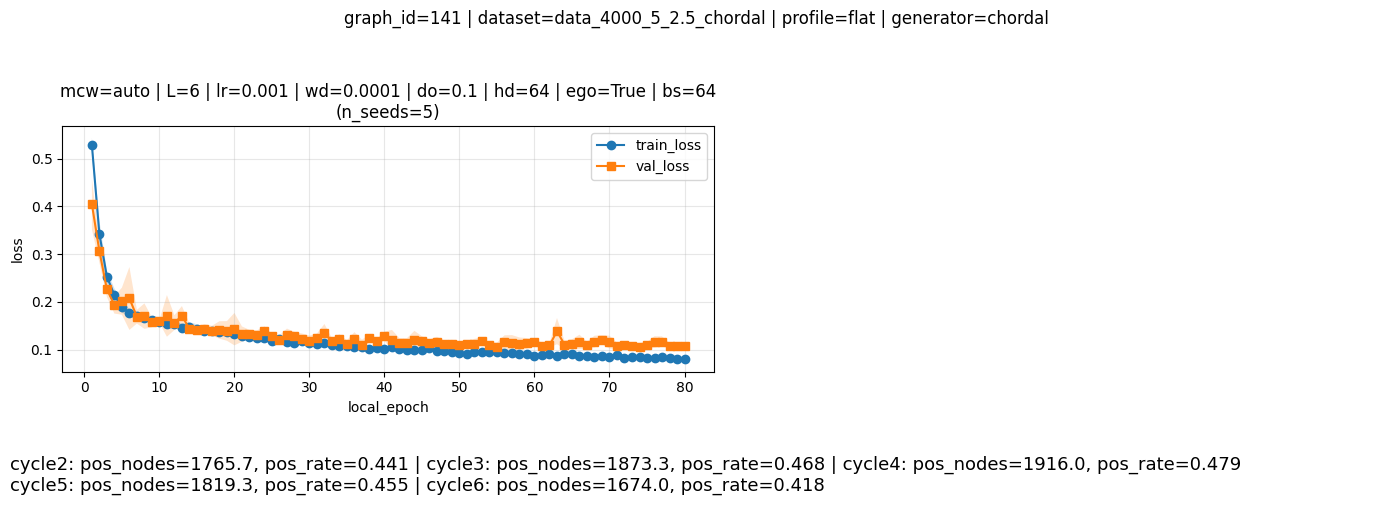

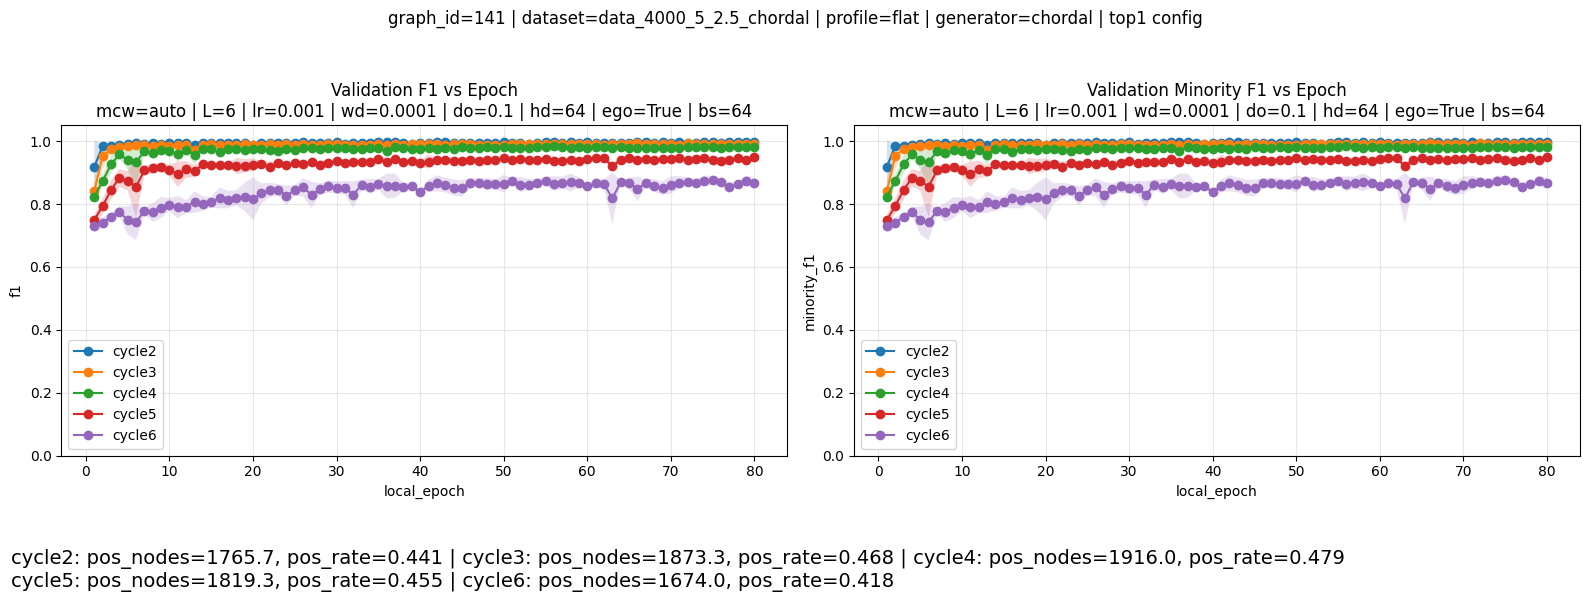

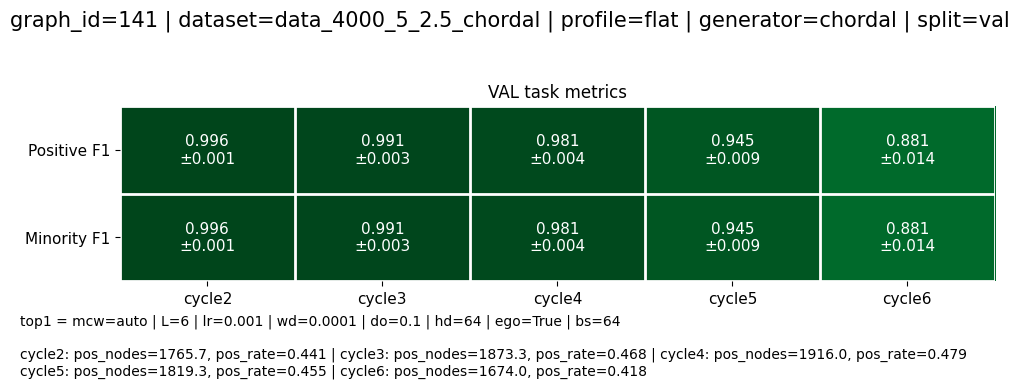

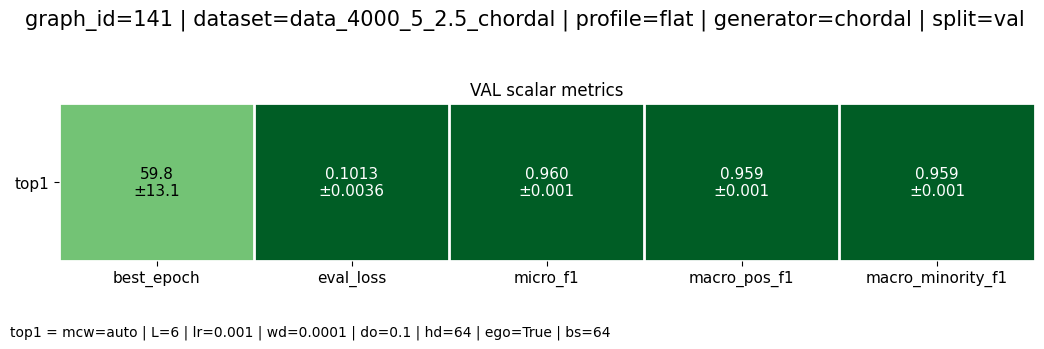

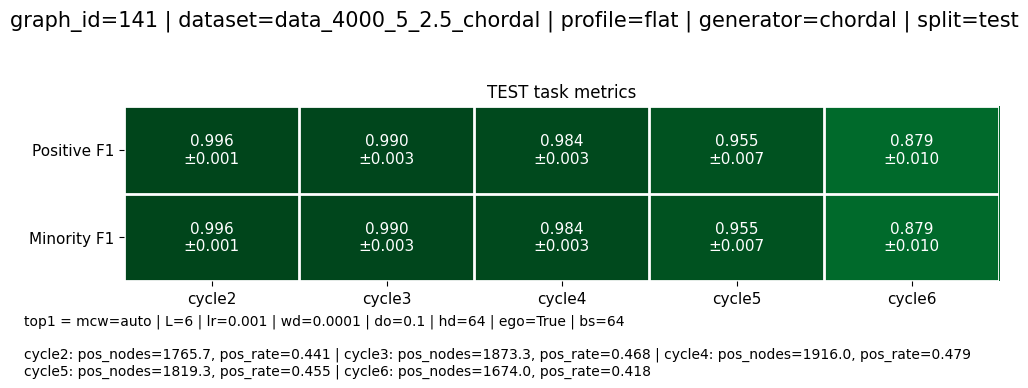

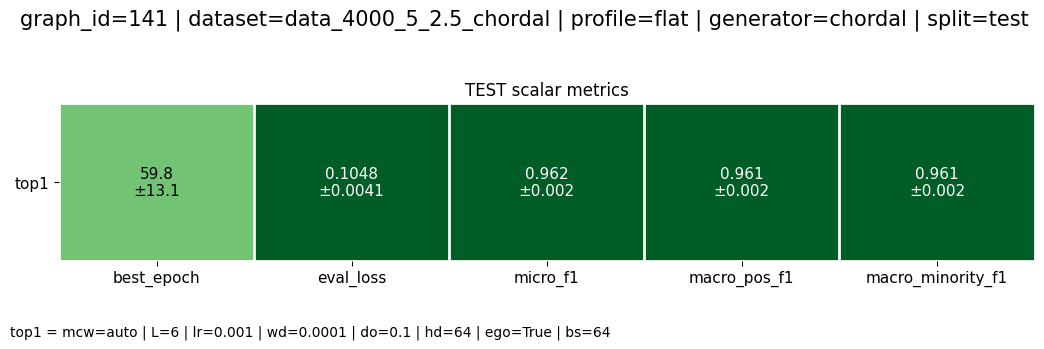


graph_id: 467
dataset_id: data_4000_5_1.5_chordal
type: chordal
selected_profile: decreasing


,task,pos_rate_mean,pos_rate_max_diff_from_mean,pos_nodes_mean,pos_nodes_max_diff_from_mean
0,cycle2,0.560,0.002,2241.000,10.000
1,cycle3,0.494,0.013,1977.667,53.667
2,cycle4,0.384,0.008,1536.000,30.000
3,cycle5,0.267,0.012,1066.667,48.667
4,cycle6,0.156,0.006,623.000,22.000



Best overall config:
 - mcw=auto | L=6 | lr=0.001 | wd=0.0001 | do=0.1 | hd=64 | ego=True | bs=64
Best config for this graph:
 - mcw=auto | L=6 | lr=0.001 | wd=0.0001 | do=0.1 | hd=64 | ego=True | bs=64


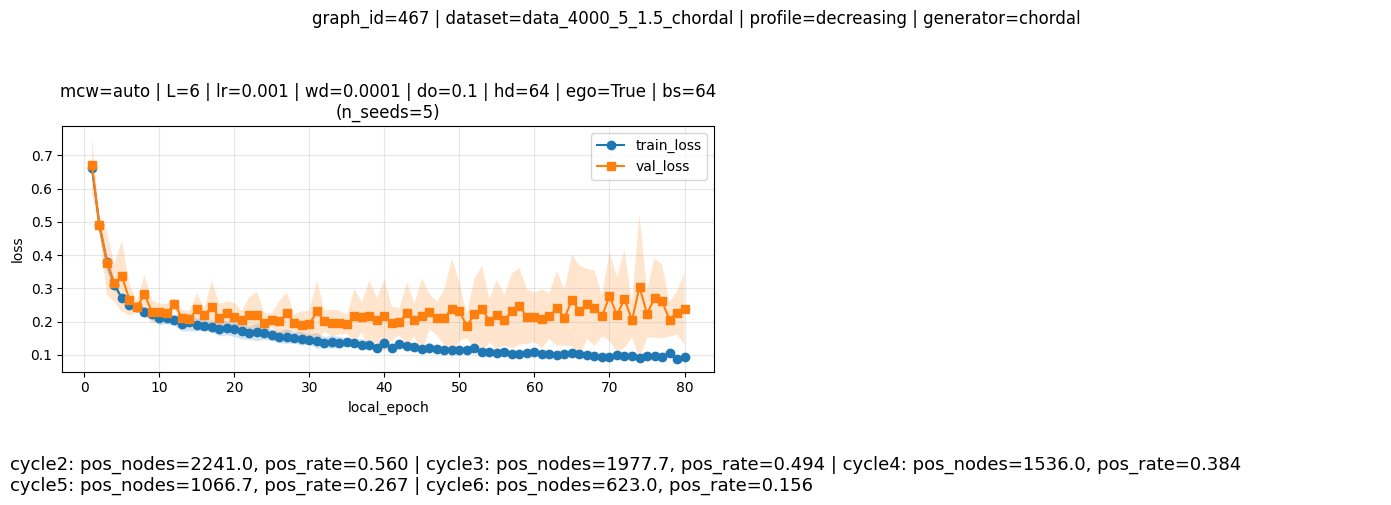

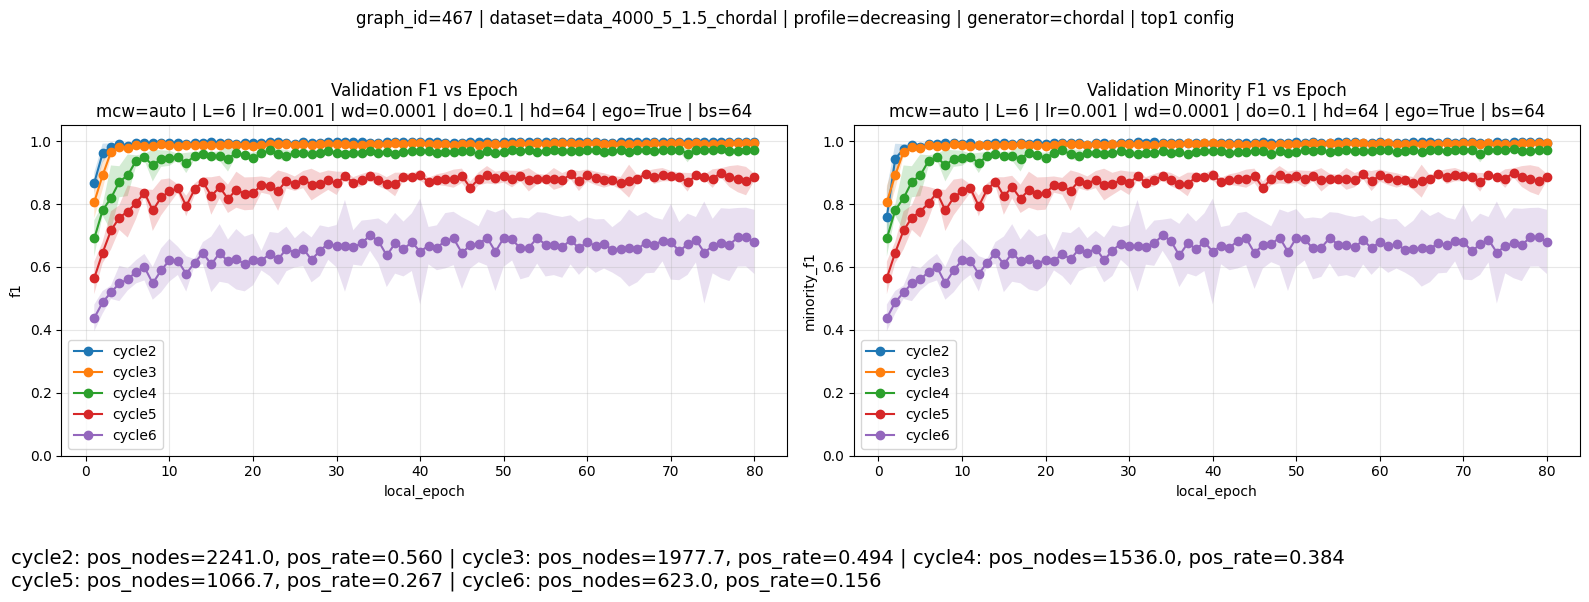

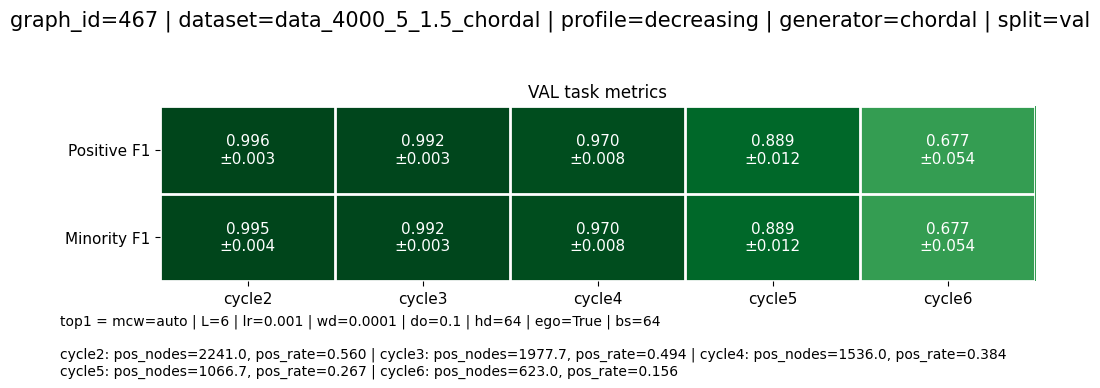

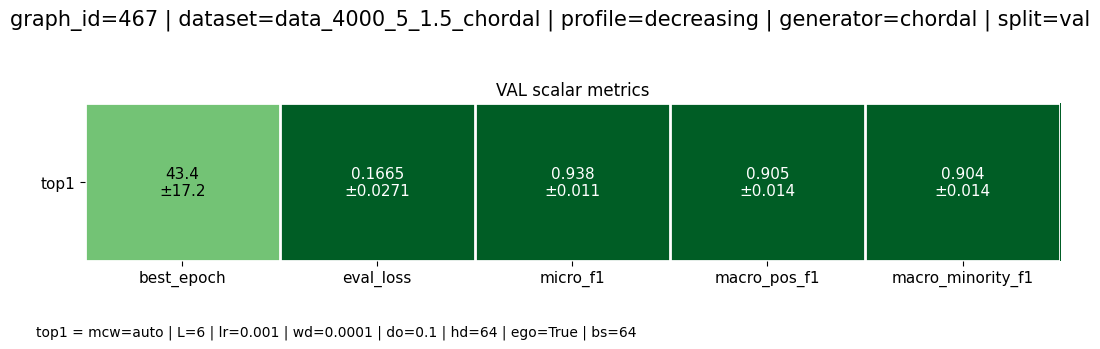

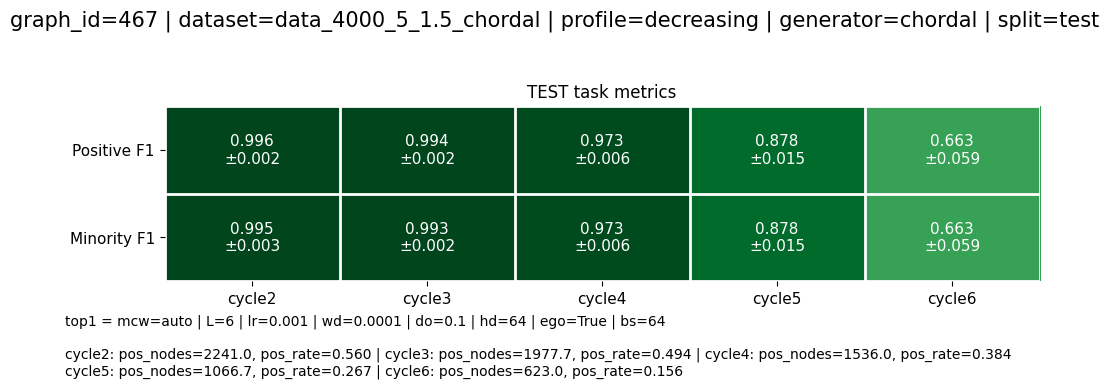

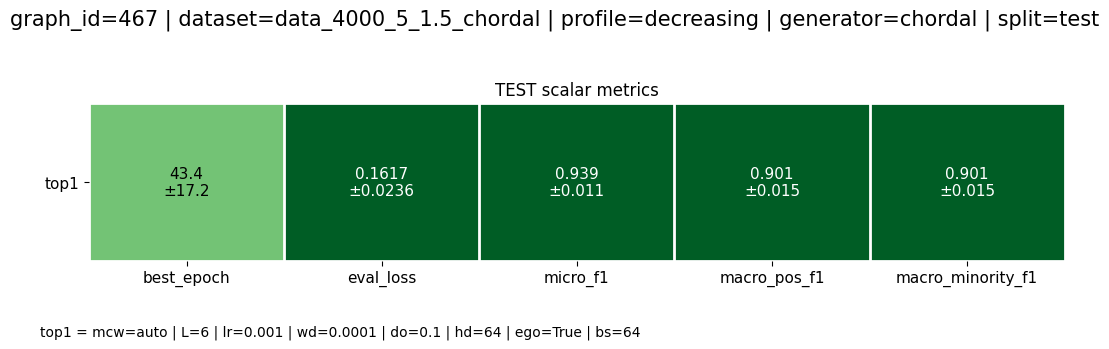


graph_id: 660
dataset_id: data_4000_5_11_chordal
type: chordal
selected_profile: increasing


,task,pos_rate_mean,pos_rate_max_diff_from_mean,pos_nodes_mean,pos_nodes_max_diff_from_mean
0,cycle2,0.141,0.006,563.000,22.000
1,cycle3,0.222,0.011,888.667,42.667
2,cycle4,0.337,0.007,1350.000,30.000
3,cycle5,0.462,0.010,1848.667,41.667
4,cycle6,0.562,0.017,2247.667,68.333



Best overall config:
 - mcw=auto | L=6 | lr=0.001 | wd=0.0001 | do=0.1 | hd=64 | ego=True | bs=64
Best config for this graph:
 - mcw=auto | L=6 | lr=0.001 | wd=0.0001 | do=0.1 | hd=64 | ego=True | bs=64


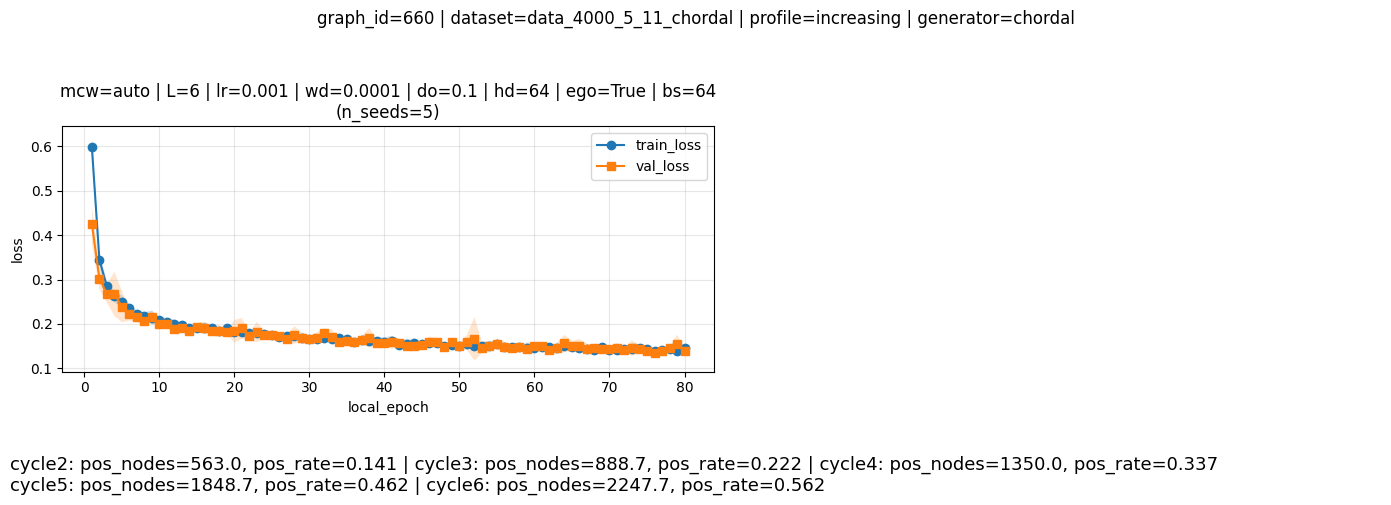

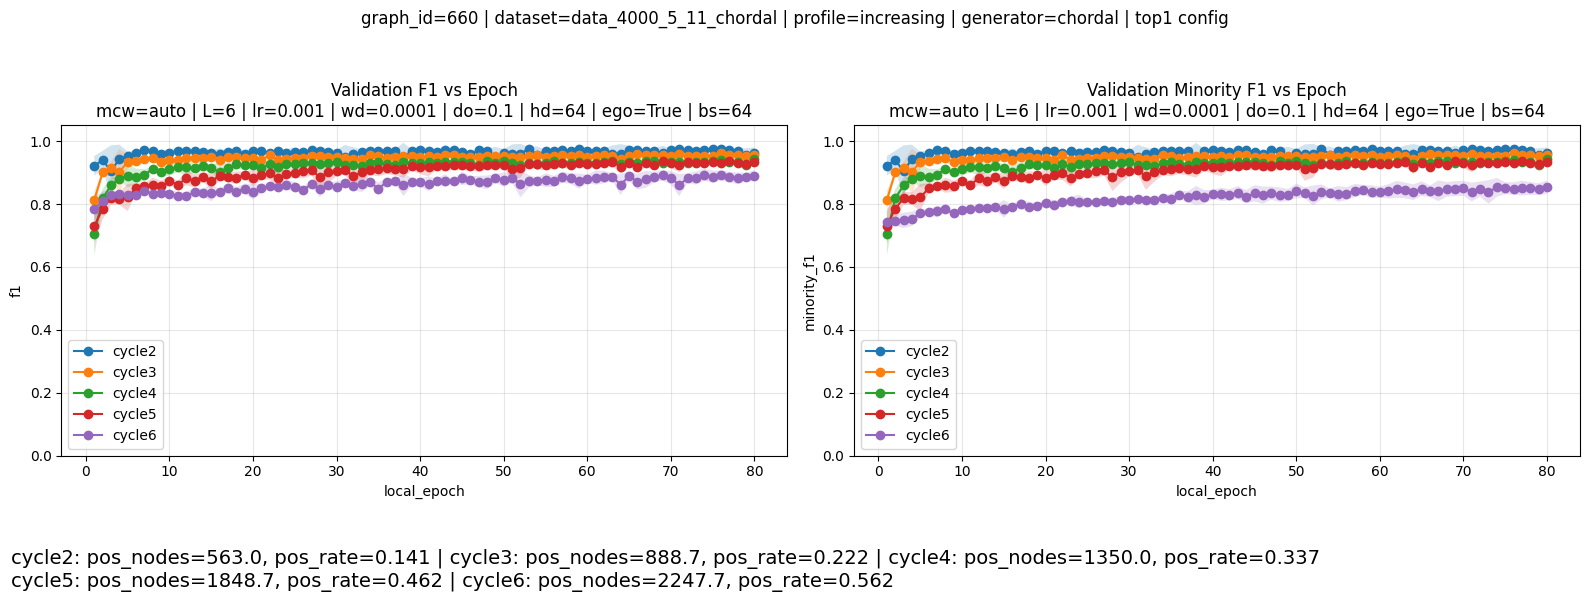

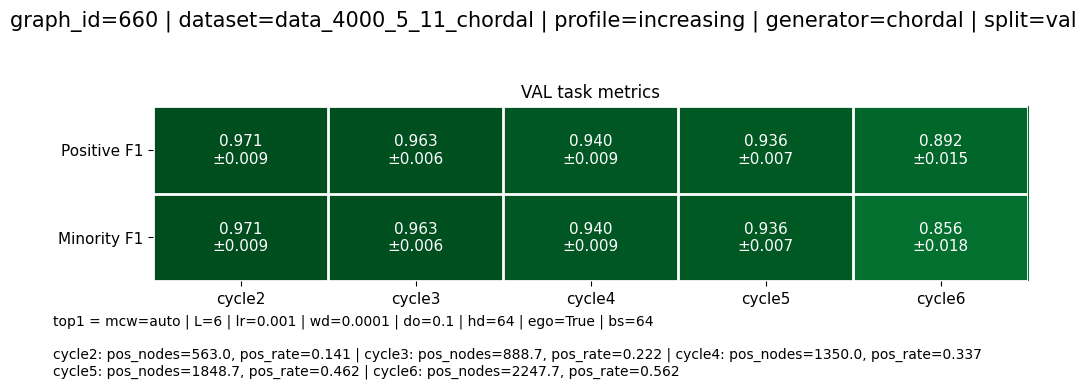

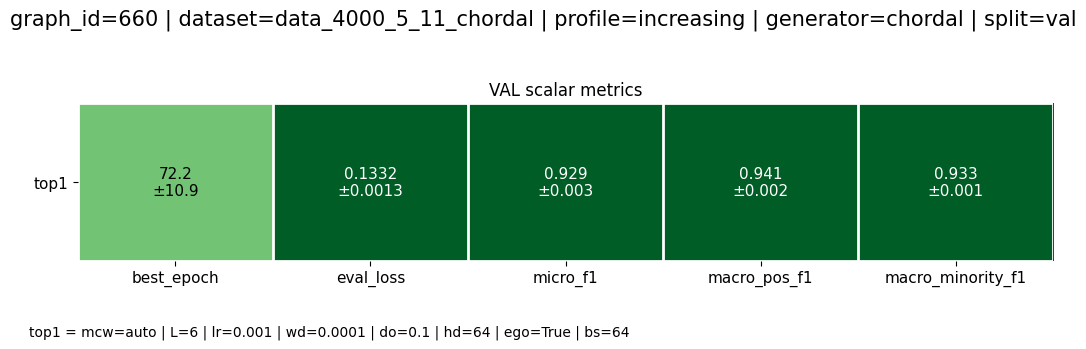

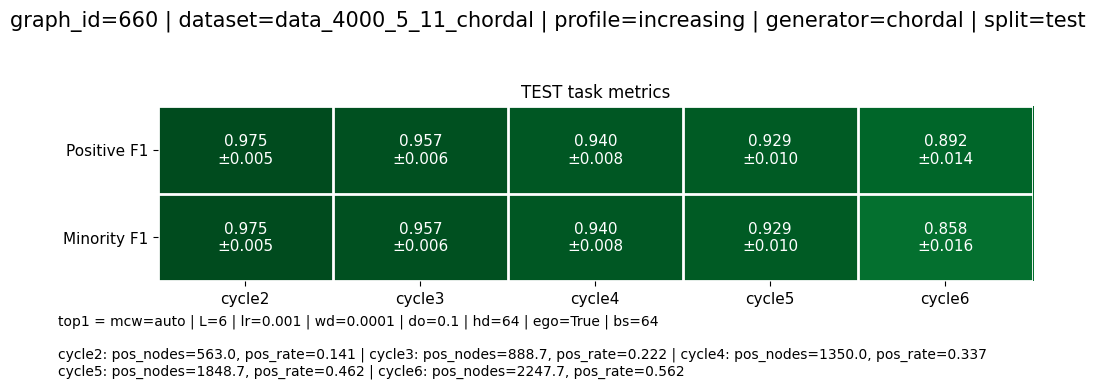

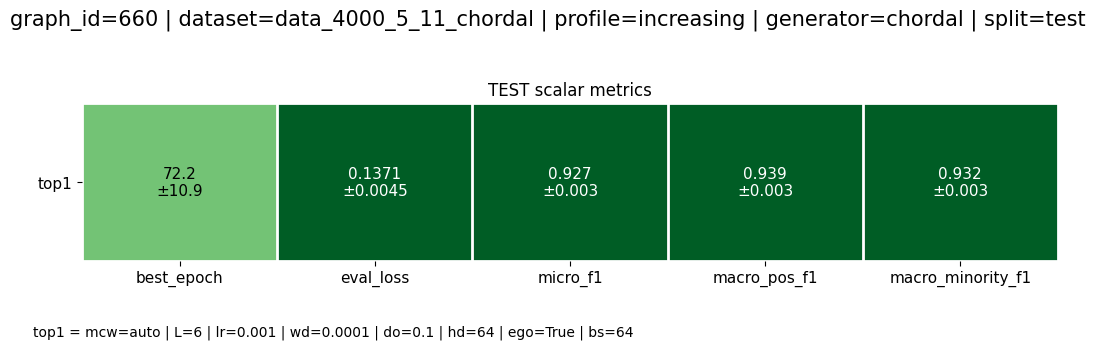


Saved loss plots:
- /Users/andreali/Documents/Subgraph_Federated_Learning/andrea/test_model_ability/experiment_plots/medium_graph/graph_141_losses_topk.png
- /Users/andreali/Documents/Subgraph_Federated_Learning/andrea/test_model_ability/experiment_plots/medium_graph/graph_467_losses_topk.png
- /Users/andreali/Documents/Subgraph_Federated_Learning/andrea/test_model_ability/experiment_plots/medium_graph/graph_660_losses_topk.png

Saved val epoch task plots:
- /Users/andreali/Documents/Subgraph_Federated_Learning/andrea/test_model_ability/experiment_plots/medium_graph/graph_141_top1_val_task_epoch_curves.png
- /Users/andreali/Documents/Subgraph_Federated_Learning/andrea/test_model_ability/experiment_plots/medium_graph/graph_467_top1_val_task_epoch_curves.png
- /Users/andreali/Documents/Subgraph_Federated_Learning/andrea/test_model_ability/experiment_plots/medium_graph/graph_660_top1_val_task_epoch_curves.png

Saved val task tables:
- /Users/andreali/Documents/Subgraph_Federated_Learning

In [29]:
# ============================================================
# MAIN RUNNER
# ============================================================

def run_all_plots(
    train_graphs_df,
    all_exp_df,
    topk_hp_df,
    best_global_config_row,
    plots_root,
    val_tasks_to_plot=None,
):
    if val_tasks_to_plot is None:
        val_tasks_to_plot = list(TASKS)

    plots_root.mkdir(parents=True, exist_ok=True)

    saved = {
        "loss": [],
        "val_epoch_task": [],
        "val_task_table": [],
        "val_scalar_table": [],
        "test_task_table": [],
        "test_scalar_table": [],
    }

    global_config = best_global_config_label(best_global_config_row)
    if global_config is None:
        print("No best overall configuration available.")
        return saved

    print("\nUsing best overall configuration for non-loss plots:")
    print(" -", global_config)

    for _, selected in train_graphs_df.iterrows():
        graph_id = selected["graph_id"]
        print("\n" + "=" * 110)
        show_selected_overview(selected, TASKS)
        graph_runs_all = collect_graph_runs(all_exp_df, graph_id)

        if graph_runs_all["run_exists"].sum() == 0:
            print("No run directories found for this graph.")
            continue

        graph_best_config = best_config_for_graph(topk_hp_df, graph_id)
        if graph_best_config is None:
            print("No graph-specific best config available.")
            continue

        footer_text = build_positive_stats_footer(
            graph_row=selected,
            task_names=TASKS,
            only_positive=False,
            tasks_per_line=3,
        )

        print("Best overall config:")
        print(" -", global_config)
        print("Best config for this graph:")
        print(" -", graph_best_config)

        # ----------------------------------------------------
        # 1) LOSS CURVES
        # ----------------------------------------------------
        loss_configs = [global_config, graph_best_config]
        loss_configs = list(dict.fromkeys(loss_configs))

        graph_runs_loss = graph_runs_all[
            graph_runs_all["config"].isin(loss_configs)
        ].copy()

        if graph_runs_loss.empty:
            print("No runs found for loss comparison configs.")
        else:
            loss_plot_path = make_loss_figure_for_graph(
                selected,
                graph_runs_loss,
                plots_root,
                configs=loss_configs,
                footer_text=footer_text,
            )
            saved["loss"].append(loss_plot_path)

        # ----------------------------------------------------
        # 2) ALL OTHER PLOTS: use ONLY best overall config
        # ----------------------------------------------------
        metric_configs = [global_config]
        graph_runs_metrics = graph_runs_all[
            graph_runs_all["config"].isin(metric_configs)
        ].copy()

        if graph_runs_metrics.empty:
            print("No runs found for best overall config on this graph.")
            continue

        # 2a) Validation per-epoch curves
        val_task_epoch_df = summarize_val_task_per_epoch(graph_runs_metrics)
        if not val_task_epoch_df.empty:
            val_task_epoch_df = val_task_epoch_df[
                val_task_epoch_df["config"].isin(metric_configs)
            ].copy()

            val_epoch_plot_path = make_top1_val_epoch_task_figure_for_graph(
                selected,
                val_task_epoch_df,
                plots_root,
                configs=metric_configs,
                task_subset=val_tasks_to_plot,
                footer_text=footer_text,
            )
            if val_epoch_plot_path is not None:
                saved["val_epoch_task"].append(val_epoch_plot_path)
        else:
            print("No val_task rows found for per-epoch validation task plot.")

        # 2b) Best-val and best-test tables
        for split_name, task_key, scalar_key in [
            ("val", "val_task_table", "val_scalar_table"),
            ("test", "test_task_table", "test_scalar_table"),
        ]:
            scalar_df, task_df = summarize_best_split(graph_runs_metrics, split_name)

            if not scalar_df.empty:
                scalar_df = scalar_df[scalar_df["config"].isin(metric_configs)].copy()
            if not task_df.empty:
                task_df = task_df[task_df["config"].isin(metric_configs)].copy()

            if not task_df.empty:
                task_plot_path = make_task_metric_table_for_graph(
                    graph_row=selected,
                    task_df=task_df,
                    save_root=plots_root,
                    split_name=split_name,
                    configs=metric_configs,
                    footer_text=footer_text,
                    use_topk=False,
                )
                saved[task_key].append(task_plot_path)
            else:
                print(f"No best_{split_name}_task rows found for best overall config.")

            if not scalar_df.empty:
                scalar_plot_path = make_scalar_metric_table_for_graph(
                    graph_row=selected,
                    scalar_df=scalar_df,
                    save_root=plots_root,
                    split_name=split_name,
                    configs=metric_configs,
                )
                saved[scalar_key].append(scalar_plot_path)
            else:
                print(f"No best_{split_name} rows found for best overall config.")

    return saved


saved_plots = run_all_plots(
    train_graphs_df=train_graphs,
    all_exp_df=all_exp,
    topk_hp_df=topk_hp,
    best_global_config_row=BEST_GLOBAL_CONFIG,
    plots_root=PLOTS_ROOT,
    val_tasks_to_plot=VAL_TASKS_TO_PLOT,
)

print("\nSaved loss plots:")
for p in saved_plots["loss"]:
    print("-", p)

print("\nSaved val epoch task plots:")
for p in saved_plots["val_epoch_task"]:
    print("-", p)

print("\nSaved val task tables:")
for p in saved_plots["val_task_table"]:
    print("-", p)

print("\nSaved val scalar tables:")
for p in saved_plots["val_scalar_table"]:
    print("-", p)

print("\nSaved test task tables:")
for p in saved_plots["test_task_table"]:
    print("-", p)

print("\nSaved test scalar tables:")
for p in saved_plots["test_scalar_table"]:
    print("-", p)

## Optional scratch cell

Use this cell for quick experiments without polluting the main pipeline.
